In [139]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sys.path.append("..")
sys.path.append("../scripts")
from scripts.paths import raw_customer_churn_path, clean_customer_churn_path, preprocessing_visuals_path
from scripts.preprocessing import load_data, inspect_data, clean_data

In [15]:
df = load_data(clean_customer_churn_path)

========== Data Load Sucessfully ==========


In [23]:
# Inspect Clean Customer Churn Data
inspect_data(df)

===== First Five Rows =====
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV Streamin

In [39]:
# Calculate the total numbers of customers
total_customers = df['customerID'].nunique()
print(f"Total Customers: {total_customers:,}")

Total Customers: 7,043


In [47]:
# Calculate the total numbers of Churned Customers 
total_churned = (df['Churn'] == "Yes").sum()
churn_rate = (total_churned / total_customers) * 100
print(f"Total Churned Customers: {total_churned:,}")
print(f"Churn Rate: {churn_rate:.2f}")


Total Churned Customers: 1,869
Churn Rate: 26.54


In [53]:
# Calculate the number of customers by churn status
churn_counts = df['Churn'].value_counts()
print(churn_counts)

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [55]:
# Calculate the number of Customers by gender
gender_counts = df['gender'].value_counts()
print(gender_counts)


gender
Male      3555
Female    3488
Name: count, dtype: int64


In [57]:
# Claculate the number of customers by senior citizen status
senior_citizen_counts = df['SeniorCitizen'].value_counts()
print(senior_citizen_counts)

SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64


Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


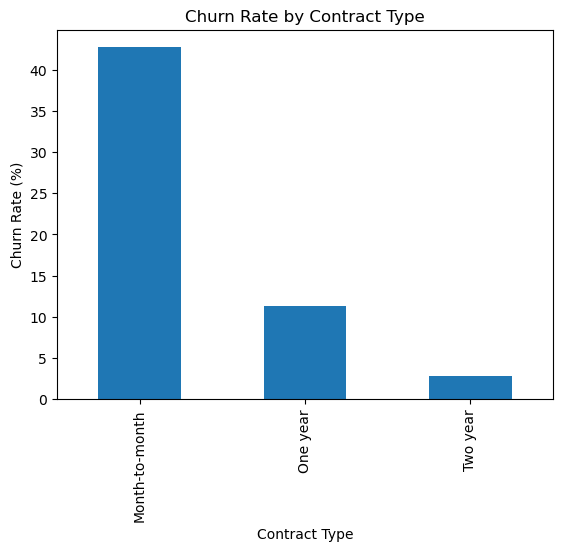

In [149]:
# Calculate churn rate by contract type
contract_churn_rate = pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
) * 100

print(contract_churn_rate)

contract_churn_rate['Yes'].plot(
    kind='bar',
    title='Churn Rate by Contract Type',
    ylabel='Churn Rate (%)',
    xlabel='Contract Type'
)
contract_type_plot = os.path.join(preprocessing_visuals_path, "churn_rate_by_contract_type.png")
plt.savefig(contract_type_plot, dpi = 300, bbox_inches ='tight')
plt.show()
plt.close()

In [61]:
df['tenure'].min(), df['tenure'].max()

(0, 72)

Churn                No        Yes
TenureGroup                       
0-12 months   52.561757  47.438243
13-24 months  71.289062  28.710938
25-48 months  79.611041  20.388959
49-72 months  90.486824   9.513176


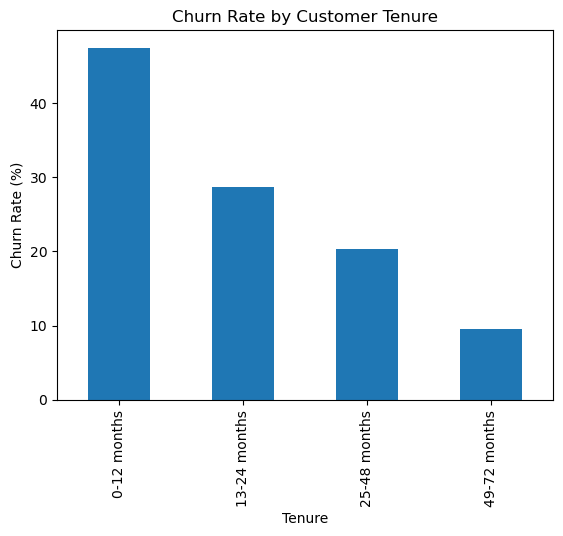

In [147]:
df['TenureGroup'] = pd.cut(
    df['tenure'],
    bins=[-1, 12, 24, 48, 72],
    labels=['0-12 months', '13-24 months', '25-48 months', '49-72 months']
)
# Calculate churn rate by tenure group
tenure_churn = pd.crosstab(
    df['TenureGroup'],
    df['Churn'],
    normalize='index'
) * 100

print(tenure_churn)
tenure_churn['Yes'].plot(
    kind='bar',
    title='Churn Rate by Customer Tenure',
    ylabel='Churn Rate (%)',
    xlabel='Tenure'
)
tenure_plot = os.path.join(preprocessing_visuals_path, 'churn_rate_by_tenue.png')
plt.savefig(tenure_plot, dpi = 300, bbox_inches ='tight')
plt.show()
plt.close()

In [67]:
df['MonthlyCharges'].min(), df['MonthlyCharges'].max()

(18.25, 118.75)

Churn                       No        Yes
MonthlyChargesGroup                      
$0-30                90.199637   9.800363
$31-60               74.071146  25.928854
$61-90               66.093881  33.906119
$91-120              67.222542  32.777458


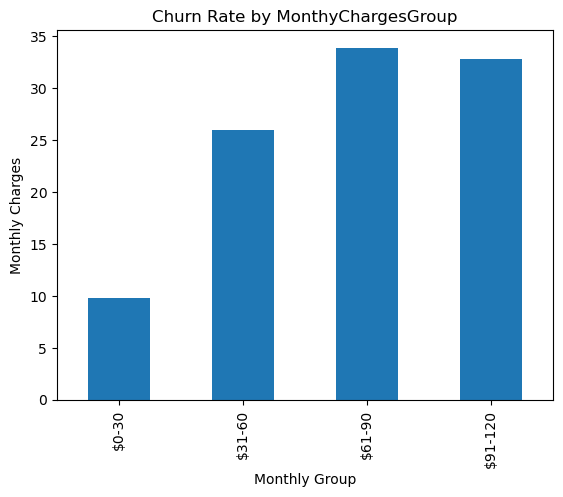

In [151]:
df['MonthlyChargesGroup'] = pd.cut(
    df['MonthlyCharges'],
    bins = [0,30,60,90,120],
    labels =['$0-30', '$31-60', '$61-90', '$91-120']
)

# Calculate churn rate by monthly charge group
monthly_charge_churn = pd.crosstab(
    df['MonthlyChargesGroup'],
    df['Churn'],
    normalize ='index'
)* 100

print(monthly_charge_churn)
monthly_charge_churn["Yes"].plot(kind ='bar',
                                 title = 'Churn Rate by MonthyChargesGroup',
                                 xlabel = 'Monthly Group',
                                ylabel = 'Monthly Charges')
# Save plot
monthly_charge_plot = os.path.join( preprocessing_visuals_path,'churn_rate_by_monthly_charges.png')
plt.savefig( monthly_charge_plot,dpi=300,bbox_inches='tight')
plt.show()
plt.close()

Churn                                  No        Yes
InternetService Contract                            
DSL             Month-to-month  67.784137  32.215863
                One year        90.701754   9.298246
                Two year        98.089172   1.910828
Fiber optic     Month-to-month  45.394737  54.605263
                One year        80.705009  19.294991
                Two year        92.773893   7.226107
No              Month-to-month  81.106870  18.893130
                One year        97.527473   2.472527
                Two year        99.216301   0.783699


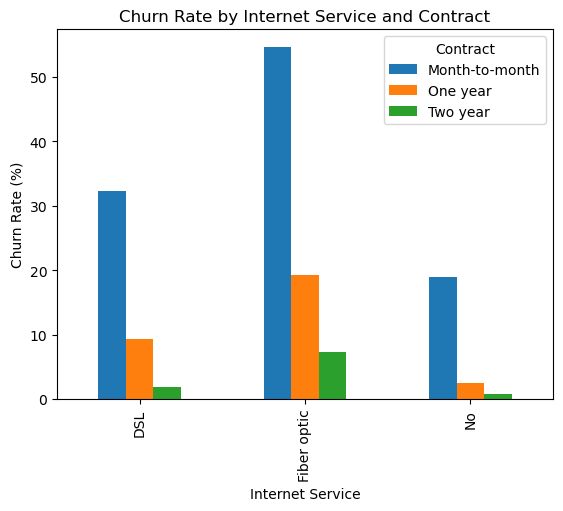

In [153]:
# Calculate churn rate by internet service and contract
internet_contract_churn = pd.crosstab(
    [df['InternetService'], df['Contract']],
    df['Churn'],
    normalize='index'
) * 100

print(internet_contract_churn)
internet_contract_churn['Yes'].unstack().plot(
    kind='bar',
    title='Churn Rate by Internet Service and Contract',
    ylabel='Churn Rate (%)',
    xlabel='Internet Service'
)
# Save plot
internet_contract_plot = os.path.join(
    preprocessing_visuals_path,
    'churn_rate_by_internet_service_and_contract.png'
)

plt.savefig(
    internet_contract_plot,
    dpi=300,
    bbox_inches='tight'
)

plt.show()
plt.close()

In [127]:
# Calculate churn rate by online security service
security_churn = pd.crosstab(
    df['OnlineSecurity'],
    df['Churn'],
    normalize='index'
) * 100

print(security_churn)

Churn                       No        Yes
OnlineSecurity                           
No                   58.233276  41.766724
No internet service  92.595020   7.404980
Yes                  85.388806  14.611194


In [129]:
# Calculate churn rate by tech support
tech_support_churn = pd.crosstab(
    df['TechSupport'],
    df['Churn'],
    normalize='index'
) * 100

print(tech_support_churn)

Churn                       No        Yes
TechSupport                              
No                   58.364526  41.635474
No internet service  92.595020   7.404980
Yes                  84.833659  15.166341


In [131]:
# Calculate churn rate by internet service
internet_churn = pd.crosstab(
    df['InternetService'],
    df['Churn'],
    normalize ='index'
)* 100
print(internet_churn)

Churn                   No        Yes
InternetService                      
DSL              81.040892  18.959108
Fiber optic      58.107235  41.892765
No               92.595020   7.404980
